**Importing Necessory Libraries**

In [ ]:
!pip install pandas scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Mounting with Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/DS_H_Features Face_Parts/DS_H_Features UpperFace(HS).csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,image_name,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,DownSyndromeStatus
0,UpperFace(HS)_down_592.jpg,0.018348,0.082883,0.133894,2.615808,1.244952,3.467203,0.851571,0.304149,0.172991,...,1.286032,1.791812,0.181863,0.338497,0.00000,0.006249,0.281989,0.257888,0.084402,1
1,UpperFace(HS)_down_543.jpg,0.087162,0.363812,0.143957,2.373152,2.208775,2.565848,0.038298,0.003708,0.296167,...,0.036741,0.498961,0.270697,0.040610,0.00000,0.002543,0.158757,0.325830,0.000231,1
2,UpperFace(HS)_down_588.jpg,0.000000,0.596277,0.092745,3.440586,1.008462,1.728870,0.102882,0.094095,0.255704,...,0.992033,0.567281,0.227043,0.543437,0.00000,0.000000,0.041894,0.205068,0.002557,1
3,UpperFace(HS)_down_545.jpg,0.023026,0.152463,0.017702,3.468510,1.590389,1.092833,0.050088,0.032496,0.093187,...,2.125041,0.633708,0.376274,0.047614,0.39769,0.097632,0.012127,0.601674,0.000000,1
4,UpperFace(HS)_down_601.jpg,0.067623,0.156806,0.126919,2.508670,0.929893,3.113722,0.352639,0.000208,0.010059,...,0.000000,0.000000,0.476414,0.000000,0.00000,0.053500,0.000000,0.143059,0.000000,1


In [ ]:
#checking for null values
df.isnull().sum()

,0
image_name,0
0,0
1,0
2,0
3,0
...,...
2044,0
2045,0
2046,0
2047,0


In [ ]:
#null value count
df.isnull().sum().sum()

0

In [ ]:
#Dropping the target coloumn (DownSyndromeStatus) and 'image_name' column as it's not relevant for prediction
X=df.drop(['DownSyndromeStatus','image_name'],axis=1)
y=df['DownSyndromeStatus']

In [ ]:
#Spliting the data with 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
#Initializing the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

#Fitting the model on the training data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Prediction on the test set
y_pred = rf_model.predict(X_test)

#Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

#Classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.77
Confusion Matrix:
[[218  74]
 [ 61 241]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       292
           1       0.77      0.80      0.78       302

    accuracy                           0.77       594
   macro avg       0.77      0.77      0.77       594
weighted avg       0.77      0.77      0.77       594



**Confusion Matrix**

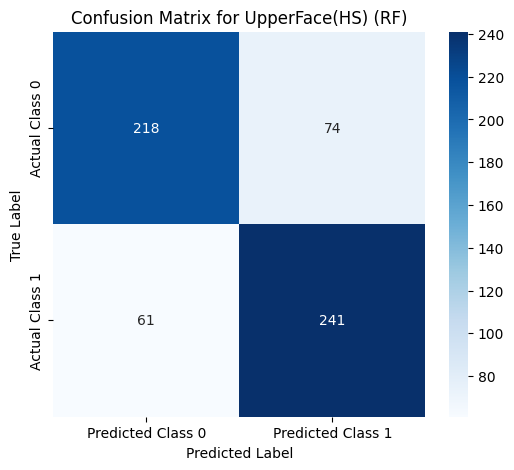

In [ ]:
#Creating heatmap for confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Class 0', 'Predicted Class 1'],
            yticklabels=['Actual Class 0', 'Actual Class 1'])

#giving labels, title, and displaying the plot
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for UpperFace(HS) (RF)')
plt.show()

**Area Under the Curve Score**

In [ ]:
#Getting predicted probabilities for the positive class
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

#Calculating False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

#Calculating the AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f'AUC Score: {auc_score:.2f}')

AUC Score: 0.85


**ROC (Receiver Operating Characteristic) Curve**

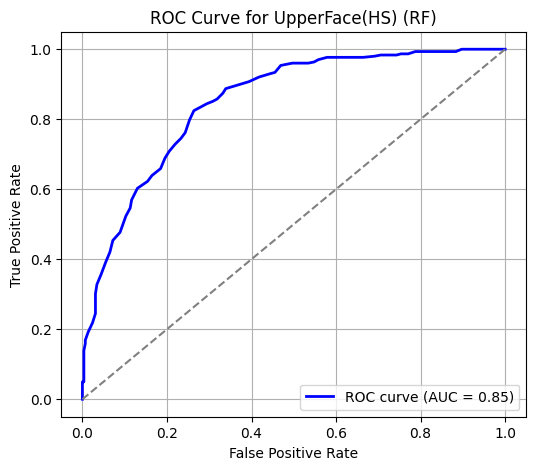

In [ ]:
#Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

#Adding labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for UpperFace(HS) (RF)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()